In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Bidirectional, LSTM, Dense, Dropout, 
    BatchNormalization, Input, LayerNormalization,
    GlobalAveragePooling1D, MultiHeadAttention, Add
)
from tensorflow.keras.callbacks import TensorBoard, EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
import tensorflow as tf

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.13.0


DATA_PATH = r"C:\Users\HP\Desktop\modeltraining2\output_video"

actions = np.array([
    'Beautiful', 'Drink', 'Eat', 'Five', 'Good', 'Hello', 'House', 'Love',
    'Man', 'Mother', 'Run', 'Thank you', 'White', 'Yellow', 'You'
])

no_sequences   = 68
sequence_length = 45
FEATURE_DIM    = 1662
NUM_CLASSES    = len(actions)

label_map = {label: idx for idx, label in enumerate(actions)}
print("Label map:", label_map)
print(f"Classes: {NUM_CLASSES} | Sequences per class: {no_sequences} | Frames: {sequence_length}")

In [3]:
DATA_PATH = r"C:\Users\HP\Desktop\modeltraining2\output_video"

actions = np.array([
    'Beautiful', 'Drink', 'Eat', 'Five', 'Good', 'Hello', 'House', 'Love',
    'Man', 'Mother', 'Run', 'Thank you', 'White', 'Yellow', 'You'
])

no_sequences   = 68
sequence_length = 45
FEATURE_DIM    = 1662
NUM_CLASSES    = len(actions)

label_map = {label: idx for idx, label in enumerate(actions)}
print("Label map:", label_map)
print(f"Classes: {NUM_CLASSES} | Sequences per class: {no_sequences} | Frames: {sequence_length}")

Label map: {'Beautiful': 0, 'Drink': 1, 'Eat': 2, 'Five': 3, 'Good': 4, 'Hello': 5, 'House': 6, 'Love': 7, 'Man': 8, 'Mother': 9, 'Run': 10, 'Thank you': 11, 'White': 12, 'Yellow': 13, 'You': 14}
Classes: 15 | Sequences per class: 68 | Frames: 45


In [4]:
sequences, labels = [], []
padded = fixed = 0

for action in actions:
    for sequence in range(no_sequences):
        window = []
        for frame_num in range(sequence_length):
            npy_path = os.path.join(DATA_PATH, action, str(sequence), f"{frame_num}.npy")
            if os.path.exists(npy_path):
                res = np.load(npy_path)
                if res.shape[0] == 258:
                    res = np.concatenate([res, np.zeros(FEATURE_DIM - 258)])
                    fixed += 1
                elif res.shape[0] != FEATURE_DIM:
                    res = np.zeros(FEATURE_DIM)
                    padded += 1
            else:
                res = np.zeros(FEATURE_DIM)
                padded += 1
            window.append(res)
        sequences.append(window)
        labels.append(label_map[action])

X = np.array(sequences, dtype=np.float32)
labels = np.array(labels)

print(f"X shape: {X.shape}")  # (1020, 45, 1662)
print(f"Padded frames: {padded} | Shape-fixed frames: {fixed}")
print(f"Label distribution: {np.bincount(labels)}")

X shape: (1020, 45, 1662)
Padded frames: 0 | Shape-fixed frames: 0
Label distribution: [68 68 68 68 68 68 68 68 68 68 68 68 68 68 68]


In [21]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Reshape for scaling: (samples*timesteps, features)
X_flat = X.reshape(-1, FEATURE_DIM)

# StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_flat)

# PCA — reduce 1662 → 256 dims (keeps ~95% variance, kills noise)
pca = PCA(n_components=256, random_state=42)
X_pca = pca.fit_transform(X_scaled)

explained = np.sum(pca.explained_variance_ratio_) * 100
print(f"Variance retained: {explained:.1f}%")

# Reshape back to (samples, timesteps, 256)
X_normalized = X_pca.reshape(X.shape[0], sequence_length, 256).astype(np.float32)
REDUCED_DIM = 256

print(f"Reduced shape: {X_normalized.shape}")  # (1020, 45, 256)

import joblib
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(pca, 'pca.pkl')
print("Scaler and PCA saved")

Variance retained: 100.0%
Reduced shape: (1020, 45, 256)
Scaler and PCA saved


In [24]:
X_train, X_test, y_train_idx, y_test_idx = train_test_split(
    X_normalized, labels,
    test_size=0.15,
    random_state=42,
    stratify=labels
)

y_train = to_categorical(y_train_idx, num_classes=NUM_CLASSES)
y_test  = to_categorical(y_test_idx,  num_classes=NUM_CLASSES)

class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_idx),
    y=y_train_idx
)
class_weight_dict = {i: float(w) for i, w in enumerate(class_weights_array)}

print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print("Class weights:", {actions[k]: round(v, 3) for k, v in class_weight_dict.items()})

Train: (867, 45, 256) | Test: (153, 45, 256)
Class weights: {'Beautiful': 0.997, 'Drink': 0.997, 'Eat': 0.997, 'Five': 1.014, 'Good': 0.997, 'Hello': 0.997, 'House': 1.014, 'Love': 0.997, 'Man': 0.997, 'Mother': 0.997, 'Run': 0.997, 'Thank you': 0.997, 'White': 1.014, 'Yellow': 0.997, 'You': 0.997}


In [22]:
X_train, X_test, y_train_idx, y_test_idx = train_test_split(
    X_normalized, labels,
    test_size=0.15,
    random_state=42,
    stratify=labels
)

y_train = to_categorical(y_train_idx, num_classes=NUM_CLASSES)
y_test  = to_categorical(y_test_idx,  num_classes=NUM_CLASSES)

class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_idx),
    y=y_train_idx
)
class_weight_dict = {i: float(w) for i, w in enumerate(class_weights_array)}

print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print("Class weights:", {actions[k]: round(v, 3) for k, v in class_weight_dict.items()})

Train: (867, 45, 256) | Test: (153, 45, 256)
Class weights: {'Beautiful': 0.997, 'Drink': 0.997, 'Eat': 0.997, 'Five': 1.014, 'Good': 0.997, 'Hello': 0.997, 'House': 1.014, 'Love': 0.997, 'Man': 0.997, 'Mother': 0.997, 'Run': 0.997, 'Thank you': 0.997, 'White': 1.014, 'Yellow': 0.997, 'You': 0.997}


In [25]:
def augment_sequence(X, noise_factor=0.01):
    X_aug = X.copy()
    # Only Gaussian noise — keep it simple
    noise = np.random.normal(0, noise_factor, X_aug.shape).astype(np.float32)
    X_aug += noise
    return X_aug

# Only 1x augmentation (don't over-inflate training set)
X_train_aug = np.array([augment_sequence(seq) for seq in X_train], dtype=np.float32)
X_train_combined = np.concatenate([X_train, X_train_aug], axis=0)
y_train_combined = np.concatenate([y_train, y_train], axis=0)

shuffle_idx = np.random.permutation(len(X_train_combined))
X_train_combined = X_train_combined[shuffle_idx]
y_train_combined = y_train_combined[shuffle_idx]

print(f"Augmented training set: {X_train_combined.shape}")

Augmented training set: (1734, 45, 256)


In [26]:
from tensorflow.keras.layers import (
    Bidirectional, LSTM, Dense, Dropout,
    BatchNormalization, Input, GlobalAveragePooling1D
)
from tensorflow.keras.models import Model
from tensorflow.keras.regularizers import l2

def build_model(input_shape, num_classes):
    """
    SMALLER model — overfitting was caused by too many parameters
    relative to dataset size (1020 samples, 15 classes).
    Rule of thumb: simpler model + strong regularization beats 
    complex model + heavy dropout.
    """
    inputs = Input(shape=input_shape)

    # Block 1
    x = Bidirectional(LSTM(64, return_sequences=True,
                           dropout=0.2,             # built-in LSTM dropout
                           recurrent_dropout=0.2,   # recurrent dropout
                           kernel_regularizer=l2(1e-3)))(inputs)
    x = BatchNormalization()(x)

    # Block 2
    x = Bidirectional(LSTM(128, return_sequences=True,
                           dropout=0.2,
                           recurrent_dropout=0.2,
                           kernel_regularizer=l2(1e-3)))(x)
    x = BatchNormalization()(x)

    # Block 3 — smaller
    x = Bidirectional(LSTM(64, return_sequences=True,
                           dropout=0.2,
                           recurrent_dropout=0.2,
                           kernel_regularizer=l2(1e-3)))(x)
    x = BatchNormalization()(x)

    # Pool across timesteps
    x = GlobalAveragePooling1D()(x)

    # Dense head — smaller than before
    x = Dense(128, activation='relu', kernel_regularizer=l2(1e-3))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)

    x = Dense(64, activation='relu', kernel_regularizer=l2(1e-3))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.2)(x)

    outputs = Dense(num_classes, activation='softmax')(x)

    return Model(inputs, outputs)


model = build_model(input_shape=(sequence_length, REDUCED_DIM), num_classes=NUM_CLASSES)
model.summary()
print(f"\nTotal parameters: {model.count_params():,}")
# Should be ~1-2M params, much less than before

Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 45, 256)]         0         
                                                                 
 bidirectional_3 (Bidirecti  (None, 45, 128)           164352    
 onal)                                                           
                                                                 
 batch_normalization_5 (Bat  (None, 45, 128)           512       
 chNormalization)                                                
                                                                 
 bidirectional_4 (Bidirecti  (None, 45, 256)           263168    
 onal)                                                           
                                                                 
 batch_normalization_6 (Bat  (None, 45, 256)           1024      
 chNormalization)                                          

In [27]:
model.compile(
    optimizer=Adam(learning_rate=1e-3, clipnorm=1.0),  # higher LR (1e-3 not 3e-4)
    loss='categorical_crossentropy',
    metrics=['categorical_accuracy']
)
print("Compiled with lr=1e-3")

Compiled with lr=1e-3


In [28]:
os.makedirs('Logs_FineTuned', exist_ok=True)
os.makedirs('checkpoints', exist_ok=True)

callbacks = [
    TensorBoard(log_dir='Logs_FineTuned'),

    ModelCheckpoint(
        filepath='checkpoints/best_model.h5',
        monitor='val_categorical_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    ),

    # Patience 40 — gives enough time to converge
    EarlyStopping(
        monitor='val_categorical_accuracy',
        patience=40,
        restore_best_weights=True,
        mode='max',
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=15,
        min_lr=1e-6,
        verbose=1
    )
]
print("Callbacks ready")

Callbacks ready


In [29]:
history = model.fit(
    X_train_combined, y_train_combined,
    epochs=300,
    validation_data=(X_test, y_test),
    batch_size=16,              # smaller batch = better generalization
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)
print("\nTraining complete!")

Epoch 1/300
109/109 [==============================] - ETA: 0s - loss: 3.7655 - categorical_accuracy: 0.2757
Epoch 1: val_categorical_accuracy improved from -inf to 0.45752, saving model to checkpoints\best_model.h5
109/109 [==============================] - 41s 205ms/step - loss: 3.7655 - categorical_accuracy: 0.2757 - val_loss: 3.3825 - val_categorical_accuracy: 0.4575 - lr: 0.0010
Epoch 2/300


D:\anaconda3\envs\mp_env\lib\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


109/109 [==============================] - ETA: 0s - loss: 2.8587 - categorical_accuracy: 0.4994
Epoch 2: val_categorical_accuracy improved from 0.45752 to 0.62092, saving model to checkpoints\best_model.h5
109/109 [==============================] - 22s 202ms/step - loss: 2.8587 - categorical_accuracy: 0.4994 - val_loss: 2.4954 - val_categorical_accuracy: 0.6209 - lr: 0.0010
Epoch 3/300
109/109 [==============================] - ETA: 0s - loss: 2.3604 - categorical_accuracy: 0.6223
Epoch 3: val_categorical_accuracy improved from 0.62092 to 0.64706, saving model to checkpoints\best_model.h5
109/109 [==============================] - 22s 204ms/step - loss: 2.3604 - categorical_accuracy: 0.6223 - val_loss: 2.2228 - val_categorical_accuracy: 0.6471 - lr: 0.0010
Epoch 4/300
109/109 [==============================] - ETA: 0s - loss: 2.0499 - categorical_accuracy: 0.6961
Epoch 4: val_categorical_accuracy improved from 0.64706 to 0.75163, saving model to checkpoints\best_model.h5
109/109 [====

In [31]:
from tensorflow.keras.models import load_model

best_model = load_model('checkpoints/best_model.h5')

train_loss, train_acc = best_model.evaluate(X_train, y_train, verbose=0)
test_loss,  test_acc  = best_model.evaluate(X_test,  y_test,  verbose=0)

print(f"\n{'='*45}")
print(f"  Train Accuracy : {train_acc:.4f} ({train_acc*100:.1f}%)")
print(f"  Test  Accuracy : {test_acc:.4f}  ({test_acc*100:.1f}%)")
print(f"  Gap            : {(train_acc - test_acc):.4f}")
print(f"{'='*45}")


  Train Accuracy : 0.9988 (99.9%)
  Test  Accuracy : 0.9216  (92.2%)
  Gap            : 0.0773


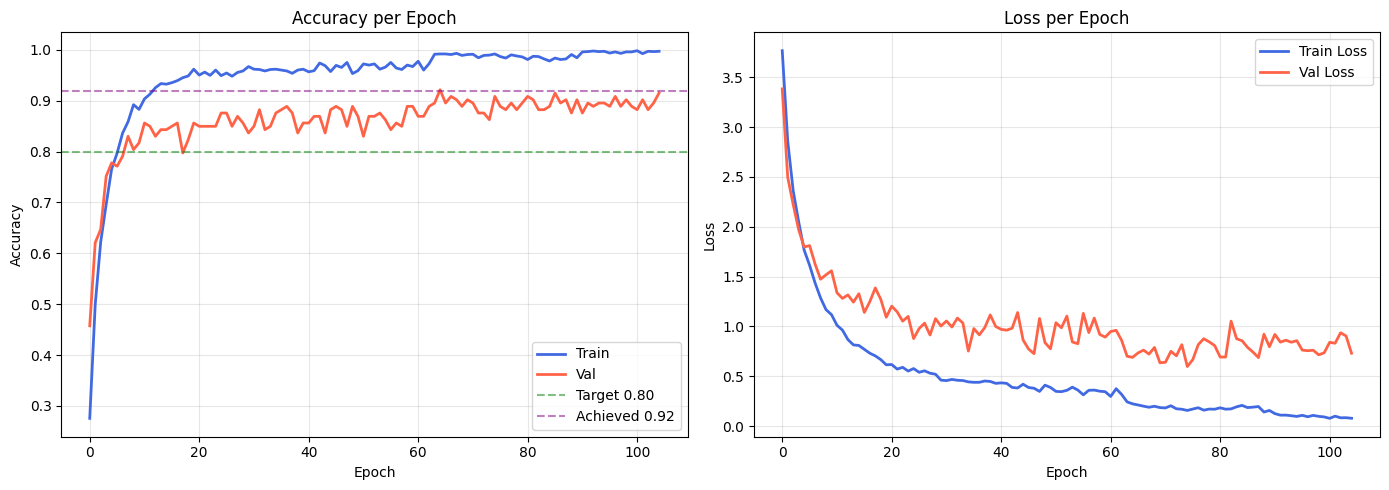

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['categorical_accuracy'],     
             label='Train', color='royalblue', linewidth=2)
axes[0].plot(history.history['val_categorical_accuracy'], 
             label='Val',   color='tomato',    linewidth=2)
axes[0].axhline(y=0.8,  color='green',  linestyle='--', alpha=0.5, label='Target 0.80')
axes[0].axhline(y=0.92, color='purple', linestyle='--', alpha=0.5, label='Achieved 0.92')
axes[0].set_title('Accuracy per Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history.history['loss'],     
             label='Train Loss', color='royalblue', linewidth=2)
axes[1].plot(history.history['val_loss'], 
             label='Val Loss',   color='tomato',    linewidth=2)
axes[1].set_title('Loss per Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves_final.png', dpi=150)
plt.show()

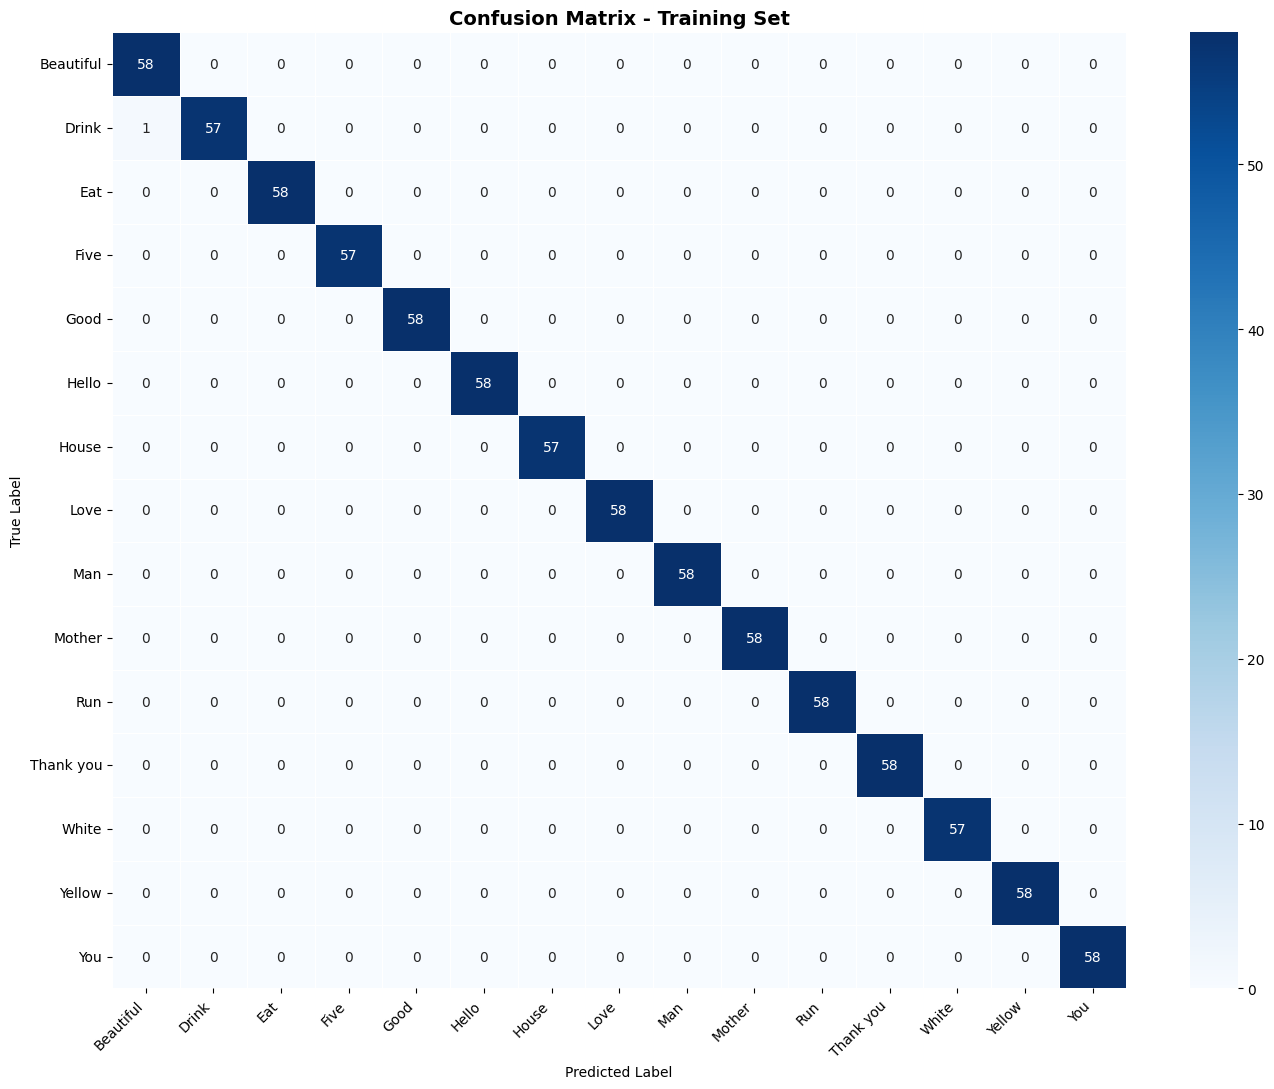


Classification Report:
              precision    recall  f1-score   support

   Beautiful       0.98      1.00      0.99        58
       Drink       1.00      0.98      0.99        58
         Eat       1.00      1.00      1.00        58
        Five       1.00      1.00      1.00        57
        Good       1.00      1.00      1.00        58
       Hello       1.00      1.00      1.00        58
       House       1.00      1.00      1.00        57
        Love       1.00      1.00      1.00        58
         Man       1.00      1.00      1.00        58
      Mother       1.00      1.00      1.00        58
         Run       1.00      1.00      1.00        58
   Thank you       1.00      1.00      1.00        58
       White       1.00      1.00      1.00        57
      Yellow       1.00      1.00      1.00        58
         You       1.00      1.00      1.00        58

    accuracy                           1.00       867
   macro avg       1.00      1.00      1.00       867
we

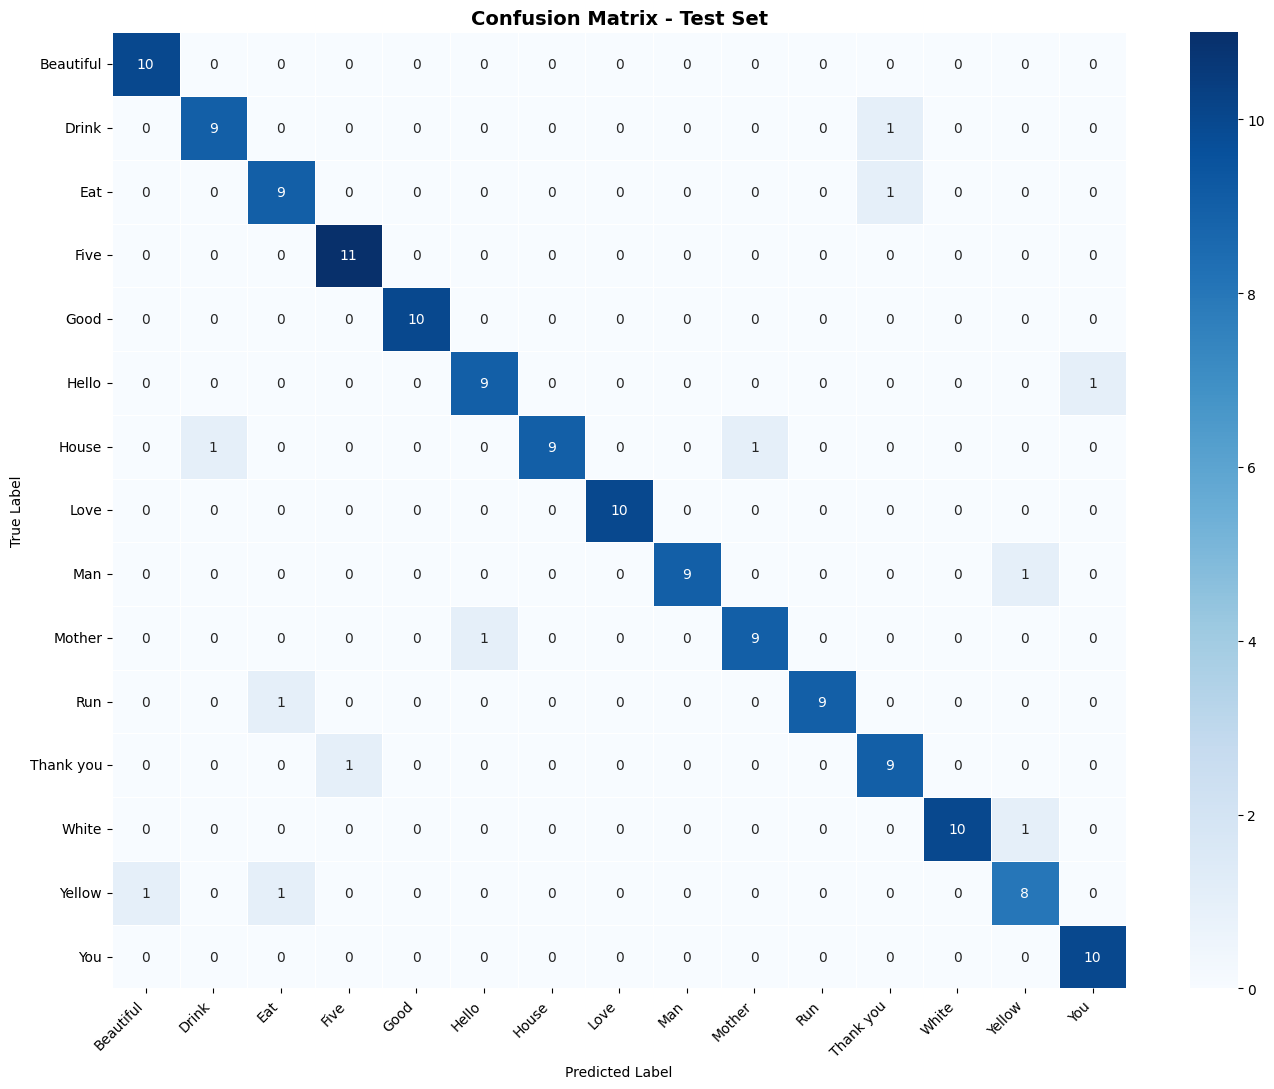


Classification Report:
              precision    recall  f1-score   support

   Beautiful       0.91      1.00      0.95        10
       Drink       0.90      0.90      0.90        10
         Eat       0.82      0.90      0.86        10
        Five       0.92      1.00      0.96        11
        Good       1.00      1.00      1.00        10
       Hello       0.90      0.90      0.90        10
       House       1.00      0.82      0.90        11
        Love       1.00      1.00      1.00        10
         Man       1.00      0.90      0.95        10
      Mother       0.90      0.90      0.90        10
         Run       1.00      0.90      0.95        10
   Thank you       0.82      0.90      0.86        10
       White       1.00      0.91      0.95        11
      Yellow       0.80      0.80      0.80        10
         You       0.91      1.00      0.95        10

    accuracy                           0.92       153
   macro avg       0.92      0.92      0.92       153
we

array([[10,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  9,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  0,  0,  0],
       [ 0,  0,  9,  0,  0,  0,  0,  0,  0,  0,  0,  1,  0,  0,  0],
       [ 0,  0,  0, 11,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0, 10,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  9,  0,  0,  0,  0,  0,  0,  0,  0,  1],
       [ 0,  1,  0,  0,  0,  0,  9,  0,  0,  1,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0, 10,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  9,  0,  0,  0,  0,  1,  0],
       [ 0,  0,  0,  0,  0,  1,  0,  0,  0,  9,  0,  0,  0,  0,  0],
       [ 0,  0,  1,  0,  0,  0,  0,  0,  0,  0,  9,  0,  0,  0,  0],
       [ 0,  0,  0,  1,  0,  0,  0,  0,  0,  0,  0,  9,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0, 10,  1,  0],
       [ 1,  0,  1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  8,  0],
       [ 0,  0,  0,  0,  0,  0,  0

In [33]:
plot_confusion_matrix(best_model, X_train, y_train, 'Confusion Matrix - Training Set')
plot_confusion_matrix(best_model, X_test,  y_test,  'Confusion Matrix - Test Set')

In [35]:
best_model.save('modeltraining2_finetuned_1.h5')

# Also save scaler and PCA (CRITICAL for real-time prediction!)
import joblib
print("best_model      → modeltraining2_finetuned_1.h5")
print("scaler          → scaler.pkl")
print("pca             → pca.pkl")
print("\n⚠️  Keep scaler.pkl and pca.pkl with your model!")
print("You MUST apply the same scaler+PCA to new data before predicting!")

best_model      → modeltraining2_finetuned_1.h5
scaler          → scaler.pkl
pca             → pca.pkl

⚠️  Keep scaler.pkl and pca.pkl with your model!
You MUST apply the same scaler+PCA to new data before predicting!


In [1]:
import cv2
import numpy as np
import mediapipe as mp
import joblib
from tensorflow.keras.models import load_model
import ipywidgets as widgets
from IPython.display import display, clear_output

# =========================
# Load model + scaler + PCA
# =========================
model = load_model('modeltraining2_finetuned_1.h5')
scaler = joblib.load('scaler.pkl')   # ← must be in same folder
pca    = joblib.load('pca.pkl')      # ← must be in same folder

actions = [
    'Beautiful', 'Drink', 'Eat', 'Five', 'Good', 'Hello', 'House',
    'Love', 'Man', 'Mother', 'Run', 'Thank you', 'White', 'Yellow', 'You'
]

sequence_length = 45
FEATURE_DIM     = 1662

# =========================
# Mediapipe Setup
# =========================
mp_holistic = mp.solutions.holistic
mp_drawing  = mp.solutions.drawing_utils

def extract_keypoints(results):
    pose = np.array([[res.x, res.y, res.z, res.visibility] 
                     for res in results.pose_landmarks.landmark]).flatten() \
           if results.pose_landmarks else np.zeros(33*4)
    face = np.array([[res.x, res.y, res.z] 
                     for res in results.face_landmarks.landmark]).flatten() \
           if results.face_landmarks else np.zeros(468*3)
    lh   = np.array([[res.x, res.y, res.z] 
                     for res in results.left_hand_landmarks.landmark]).flatten() \
           if results.left_hand_landmarks else np.zeros(21*3)
    rh   = np.array([[res.x, res.y, res.z] 
                     for res in results.right_hand_landmarks.landmark]).flatten() \
           if results.right_hand_landmarks else np.zeros(21*3)
    return np.concatenate([pose, face, lh, rh])

# =========================
# Preprocess — MUST match training
# =========================
def preprocess_sequence(sequence_1662):
    """
    Input:  numpy array (45, 1662) — raw keypoints
    Output: numpy array (1, 45, 256) — scaled + PCA reduced
    """
    # Step 1: Fix shape mismatches (same as training)
    fixed = []
    for frame in sequence_1662:
        if frame.shape[0] == 258:
            frame = np.concatenate([frame, np.zeros(FEATURE_DIM - 258)])
        elif frame.shape[0] != FEATURE_DIM:
            frame = np.zeros(FEATURE_DIM)
        fixed.append(frame)
    seq = np.array(fixed, dtype=np.float32)           # (45, 1662)

    # Step 2: StandardScaler  — same scaler used in training
    seq_scaled = scaler.transform(seq)                 # (45, 1662)

    # Step 3: PCA reduce — same PCA used in training
    seq_pca = pca.transform(seq_scaled)                # (45, 256)

    # Step 4: Add batch dimension
    return seq_pca[np.newaxis, ...].astype(np.float32) # (1, 45, 256)

# =========================
# Predict from video file
# =========================
def predict_sign_video(video_path):
    cap    = cv2.VideoCapture(video_path)
    frames = []

    with mp_holistic.Holistic(
        min_detection_confidence=0.5,
        min_tracking_confidence=0.5
    ) as holistic:
        while True:
            ret, frame = cap.read()
            if not ret:
                break
            image = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            image.flags.writeable = False
            results = holistic.process(image)
            image.flags.writeable = True
            keypoints = extract_keypoints(results)
            frames.append(keypoints)
    cap.release()

    # Pad or trim to exactly 45 frames
    if len(frames) == 0:
        print("⚠️ No frames extracted from video!")
        return None, 0.0

    if len(frames) < sequence_length:
        pad = [np.zeros(FEATURE_DIM)] * (sequence_length - len(frames))
        frames.extend(pad)
    else:
        # Use middle 45 frames — better than last 45 for most signs
        start = (len(frames) - sequence_length) // 2
        frames = frames[start : start + sequence_length]

    sequence = np.array(frames, dtype=np.float32)      # (45, 1662)

    # ✅ Apply scaler + PCA before predicting
    model_input = preprocess_sequence(sequence)         # (1, 45, 256)

    pred       = model.predict(model_input, verbose=0)[0]
    class_idx  = np.argmax(pred)
    confidence = float(pred[class_idx])

    return actions[class_idx], confidence

# =========================
# Jupyter Upload Widget
# =========================
upload_btn = widgets.FileUpload(accept=".mp4", multiple=False)
output     = widgets.Output()

def on_upload(change):
    with output:
        clear_output()
        if not upload_btn.value:
            print("No file uploaded")
            return

        # Handle both dict and tuple formats
        if isinstance(upload_btn.value, tuple):
            uploaded_file = upload_btn.value[0]
        elif isinstance(upload_btn.value, dict):
            uploaded_file = list(upload_btn.value.values())[0]
        else:
            print("Unknown upload format")
            return

        content   = uploaded_file['content']
        temp_path = "temp_video.mp4"

        with open(temp_path, "wb") as f:
            f.write(content)

        print("Video uploaded! Processing...")

        try:
            sign, confidence = predict_sign_video(temp_path)
            if sign:
                print(f"\n✅ Predicted Sign : {sign}")
                print(f"   Confidence     : {confidence:.2%}")
                
                # Show warning if confidence is low
                if confidence < 0.6:
                    print(f"   ⚠️  Low confidence — try a clearer video")
        except Exception as e:
            print(f"❌ Error during prediction: {e}")
            import traceback
            traceback.print_exc()

upload_btn.observe(on_upload, names='value')
display(upload_btn, output)

FileUpload(value=(), accept='.mp4', description='Upload')

Output()

In [2]:
import cv2
import numpy as np
import mediapipe as mp
import joblib
from tensorflow.keras.models import load_model
from IPython.display import display, clear_output
import time

# =========================
# Load model + scaler + PCA
# =========================
model = load_model('modeltraining2_finetuned_1.h5')
scaler = joblib.load('scaler.pkl')
pca    = joblib.load('pca.pkl')

actions = [
    'Beautiful', 'Drink', 'Eat', 'Five', 'Good', 'Hello', 'House',
    'Love', 'Man', 'Mother', 'Run', 'Thank you', 'White', 'Yellow', 'You'
]

sequence_length = 45
FEATURE_DIM     = 1662

# =========================
# Mediapipe Setup
# =========================
mp_holistic = mp.solutions.holistic
mp_drawing  = mp.solutions.drawing_utils

# =========================
# Extract keypoints
# =========================
def extract_keypoints(results):

    pose = np.array([
        [res.x, res.y, res.z, res.visibility]
        for res in results.pose_landmarks.landmark
    ]).flatten() if results.pose_landmarks else np.zeros(33*4)

    face = np.array([
        [res.x, res.y, res.z]
        for res in results.face_landmarks.landmark
    ]).flatten() if results.face_landmarks else np.zeros(468*3)

    lh = np.array([
        [res.x, res.y, res.z]
        for res in results.left_hand_landmarks.landmark
    ]).flatten() if results.left_hand_landmarks else np.zeros(21*3)

    rh = np.array([
        [res.x, res.y, res.z]
        for res in results.right_hand_landmarks.landmark
    ]).flatten() if results.right_hand_landmarks else np.zeros(21*3)

    return np.concatenate([pose, face, lh, rh])

# =========================
# Preprocess sequence
# =========================
def preprocess_sequence(sequence_1662):

    fixed = []

    for frame in sequence_1662:

        if frame.shape[0] == 258:
            frame = np.concatenate(
                [frame, np.zeros(FEATURE_DIM - 258)]
            )

        elif frame.shape[0] != FEATURE_DIM:
            frame = np.zeros(FEATURE_DIM)

        fixed.append(frame)

    seq = np.array(fixed, dtype=np.float32)

    # Scale
    seq_scaled = scaler.transform(seq)

    # PCA
    seq_pca = pca.transform(seq_scaled)

    return seq_pca[np.newaxis, ...].astype(np.float32)

# =========================
# Webcam Prediction
# =========================
def start_webcam_prediction():

    cap = cv2.VideoCapture(0)

    sequence = []
    last_prediction = ""
    last_time = 0

    with mp_holistic.Holistic(
        min_detection_confidence=0.5,
        min_tracking_confidence=0.5
    ) as holistic:

        while cap.isOpened():

            ret, frame = cap.read()

            if not ret:
                print("Camera not working")
                break

            # Convert color
            image = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            image.flags.writeable = False

            results = holistic.process(image)

            image.flags.writeable = True
            image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)

            # Draw landmarks
            mp_drawing.draw_landmarks(
                image,
                results.pose_landmarks,
                mp_holistic.POSE_CONNECTIONS
            )

            mp_drawing.draw_landmarks(
                image,
                results.left_hand_landmarks,
                mp_holistic.HAND_CONNECTIONS
            )

            mp_drawing.draw_landmarks(
                image,
                results.right_hand_landmarks,
                mp_holistic.HAND_CONNECTIONS
            )

            # Extract keypoints
            keypoints = extract_keypoints(results)

            sequence.append(keypoints)

            if len(sequence) > sequence_length:
                sequence.pop(0)

            # Predict every 1 second
            if len(sequence) == sequence_length:

                current_time = time.time()

                if current_time - last_time > 1:

                    model_input = preprocess_sequence(
                        np.array(sequence)
                    )

                    pred = model.predict(
                        model_input,
                        verbose=0
                    )[0]

                    class_idx = np.argmax(pred)

                    confidence = pred[class_idx]

                    if confidence > 0.6:

                        last_prediction = (
                            f"{actions[class_idx]} "
                            f"({confidence:.2f})"
                        )

                    else:

                        last_prediction = (
                            "Low confidence"
                        )

                    last_time = current_time

            # Show prediction
            cv2.putText(
                image,
                last_prediction,
                (10, 40),
                cv2.FONT_HERSHEY_SIMPLEX,
                1,
                (0, 255, 0),
                2,
                cv2.LINE_AA
            )

            cv2.imshow(
                "Live Sign Detection",
                image
            )

            # Press Q to exit
            if cv2.waitKey(10) & 0xFF == ord('q'):
                break

    cap.release()
    cv2.destroyAllWindows()

# =========================
# Run webcam
# =========================
start_webcam_prediction()